Formula de la tecnica OTSU

Se considera a la imagen como dos valores distitos, donde el histograma solo constaria de 2 picos, el umbral se encontraria en medio de estos valores, el metodo otsu busca el valor del umbral global mas optimo apartir del histograma de de la imagen, la formula calcula el historial y lo normaliza para que su uso sea mas comodo y ademas busca las probabilidades o de manera arbitraria el valor del umbral optimo para ser usado

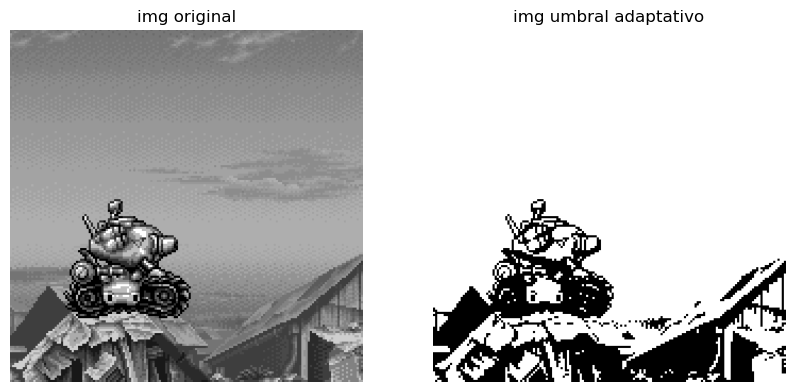

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def formula_OTSU(imagen):
    #calcular y normalizar el histograma
    hist = cv2.calcHist([imagen],[0],None,[256],[0,256])
    hist_norm = hist.ravel()/hist.sum()
    Q = hist_norm.cumsum()
 
    bins = np.arange(256)
 
    fn_min = np.inf
    thresh = -1
 
    for i in range(1,256):
        p1,p2 = np.hsplit(hist_norm,[i]) #probabilidades
        q1,q2 = Q[i],Q[255]-Q[i] 
        if q1 < 1.e-6 or q2 < 1.e-6:
            continue
        b1,b2 = np.hsplit(bins,[i]) 
 
        #encuentra las medias y variaciones
        m1,m2 = np.sum(p1*b1)/q1, np.sum(p2*b2)/q2
        v1,v2 = np.sum(((b1-m1)**2)*p1)/q1,np.sum(((b2-m2)**2)*p2)/q2
 
       
        fn = v1*q1 + v2*q2
        if fn < fn_min:
            fn_min = fn
            thresh = i

    img_otsu = imagen>=thresh
    return img_otsu
    


imagen = cv2.imread('imgGIF2.png', 0)

umbral_OTSU = formula_OTSU(imagen)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.title('img original')
plt.imshow(imagen, cmap='gray')
plt.axis('off')

plt.subplot(1,2,2)
plt.title('img umbral adaptativo')
plt.imshow(umbral_OTSU, cmap='gray')
plt.axis('off')

plt.show()
